In [1]:
from pydantic import BaseModel, Field
from typing import List

In [2]:
class CarpetRegion(BaseModel):
    start_hz: float = Field(..., description="Start frequency in Hz")
    end_hz: float = Field(..., description="End frequency in Hz")

class Wave(BaseModel):
    time: List[float] = Field(..., description="Time points of the wave")
    signal: List[float] = Field(..., description="Signal values")

class Model:

    def __init__(self, **params):

        # Store hyperparameters if needed
        # self.params = params
        raise NotImplementedError("Model initialization not implemented.")

    def predict(self, wave: Wave) -> List[CarpetRegion]:
        """
        Predict carpet regions from a given wave.
        This should be implemented with actual logic.
        """
        # Example placeholder
        raise NotImplementedError("Predict method not implemented.")

In [3]:
# dataloader
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
import csv
from typing import Iterator, Optional, Tuple, List


@dataclass(frozen=True)
class WaveSample:
    sample_id: str
    wave: Wave


class Part2WaveDataLoader:
    """
    Simple loader for `data/part_2/*.csv` files with columns: `t,data`.
    Each item yields a `WaveSample(sample_id, Wave(time, signal))`.
    """

    def __init__(
        self,
        root_dir: str | Path = Path("data/part_2"),
        pattern: str = "*.csv",
        *,
        sort: bool = True,
        limit: Optional[int] = None,
    ) -> None:
        root_path = Path(root_dir)
        if not root_path.is_absolute():
            root_path = (Path.cwd() / root_path).resolve()
        if not root_path.exists():
            raise FileNotFoundError(
                f"Could not find data directory: {root_path}. "
                "Run the notebook from the repo root or pass an absolute path."
            )
        self.root_dir = root_path
        files = list(self.root_dir.glob(pattern))
        if sort:
            files.sort(key=lambda p: p.name)
        if limit is not None:
            files = files[:limit]
        self.files: List[Path] = files

    def __len__(self) -> int:
        return len(self.files)

    def _read_csv(self, path: Path) -> Tuple[List[float], List[float]]:
        times: List[float] = []
        values: List[float] = []
        with path.open("r", newline="") as f:
            reader = csv.DictReader(f)
            if reader.fieldnames is None:
                raise ValueError(f"No header found in {path}")
            for row in reader:
                if not row:
                    continue
                t = row.get("t")
                x = row.get("data")
                if t is None or x is None:
                    raise ValueError(f"Expected columns 't' and 'data' in {path}")
                times.append(float(t))
                values.append(float(x))
        return times, values

    def get(self, index: int) -> WaveSample:
        path = self.files[index]
        times, values = self._read_csv(path)
        wave = Wave(time=times, signal=values)
        return WaveSample(sample_id=path.stem, wave=wave)

    def __iter__(self) -> Iterator[WaveSample]:
        for i in range(len(self)):
            yield self.get(i)


# Example usage (uncomment)
# loader = Part2WaveDataLoader()
# print(f"Found {len(loader)} files under {loader.root_dir}")
# first = loader.get(0)
# print(first.sample_id, len(first.wave.time), len(first.wave.signal))

In [ ]:
# Plotting + preprocessing utilities (reusable)
from __future__ import annotations

import math
from dataclasses import dataclass
from typing import Callable, Iterable, Optional, Sequence, Tuple
import numpy as np
import matplotlib.pyplot as plt

try:
    from scipy import signal  # type: ignore
except Exception as e:  # pragma: no cover
    raise ImportError("scipy is required for low-pass filtering in this notebook") from e


@dataclass(frozen=True)
class Series:
    series_id: str
    t: np.ndarray
    x: np.ndarray


def waves_from_loader(loader: Part2WaveDataLoader) -> list[Series]:
    out: list[Series] = []
    for sample in loader:
        out.append(
            Series(
                series_id=sample.sample_id,
                t=np.asarray(sample.wave.time, dtype=float),
                x=np.asarray(sample.wave.signal, dtype=float),
            )
        )
    return out


def resample_uniform(t: np.ndarray, x: np.ndarray, *, fs: float) -> Tuple[np.ndarray, np.ndarray]:
    """Resample to a uniform grid using linear interpolation."""
    if t.size < 2:
        raise ValueError("Need at least 2 samples to resample")
    if fs <= 0:
        raise ValueError("fs must be > 0")
    t0 = float(t[0])
    t1 = float(t[-1])
    if t1 <= t0:
        raise ValueError("Time array must be strictly increasing")
    dt = 1.0 / fs
    t_uniform = np.arange(t0, t1, dt, dtype=float)
    x_uniform = np.interp(t_uniform, t, x).astype(float)
    return t_uniform, x_uniform


def buffer_znorm_first_window(x: np.ndarray, *, window_samples: int) -> np.ndarray:
    """
    Z-normalize using mean/std computed from ONLY the first `window_samples` of the signal,
    then apply those fixed stats to the entire signal.
    """
    if window_samples <= 0:
        raise ValueError("window_samples must be > 0")
    x = np.asarray(x, dtype=float)
    if x.size == 0:
        return x.copy()
    w = int(min(window_samples, x.size))
    hist = x[:w]
    mu = float(hist.mean())
    sigma = float(hist.std(ddof=0))
    if sigma == 0.0 or not np.isfinite(sigma):
        return np.zeros_like(x, dtype=float)
    return ((x - mu) / sigma).astype(float)


def lowpass_filter(
    x: np.ndarray,
    *,
    fs: float,
    cutoff_hz: float,
    order: int = 4,
    zero_phase: bool = False,
) -> np.ndarray:
    """
    Low-pass filter using a Butterworth IIR filter (SOS).
    - `zero_phase=False` uses `sosfilt` (causal; no future leakage; phase delay).
    - `zero_phase=True` uses `sosfiltfilt` (acausal; no phase delay; uses future samples).
    """
    if cutoff_hz <= 0:
        raise ValueError("cutoff_hz must be > 0")
    nyq = 0.5 * fs
    if cutoff_hz >= nyq:
        return np.asarray(x, dtype=float)
    sos = signal.butter(order, cutoff_hz / nyq, btype="lowpass", output="sos")
    x = np.asarray(x, dtype=float)
    if zero_phase:
        return signal.sosfiltfilt(sos, x).astype(float)
    return signal.sosfilt(sos, x).astype(float)


def preprocess_resample_and_znorm(
    s: Series,
    *,
    fs: float,
    buffer_seconds: float = 0.1,
    drop_first_buffer: bool = False,
    lowpass_cutoff_hz: Optional[float] = None,
    lowpass_order: int = 4,
    lowpass_zero_phase: bool = False,
) -> Series:
    t_u, x_u = resample_uniform(s.t, s.x, fs=fs)
    window_samples = max(1, int(round(buffer_seconds * fs)))
    z = buffer_znorm_first_window(x_u, window_samples=window_samples)
    if lowpass_cutoff_hz is not None:
        z = lowpass_filter(
            z, fs=fs, cutoff_hz=float(lowpass_cutoff_hz), order=lowpass_order, zero_phase=lowpass_zero_phase
        )
    if drop_first_buffer and window_samples < z.size:
        return Series(series_id=s.series_id, t=t_u[window_samples:], x=z[window_samples:])
    return Series(series_id=s.series_id, t=t_u, x=z)


def fft_magnitude(x: np.ndarray, *, fs: float) -> Tuple[np.ndarray, np.ndarray]:
    x = np.asarray(x, dtype=float)
    if x.size < 2:
        raise ValueError("Need at least 2 samples for FFT")
    y = np.fft.rfft(x)
    freqs = np.fft.rfftfreq(x.size, d=1.0 / fs)
    mag = np.abs(y)
    return freqs, mag


def plot_series_grid(
    series: Sequence[Series],
    *,
    ncols: int = 4,
    max_points: Optional[int] = 5000,
    x_label: str = "t",
    y_label: str = "data",
    title: Optional[str] = None,
    xlim: Optional[Tuple[float, float]] = None,
    ylim: Optional[Tuple[float, float]] = None,
) -> None:
    n = len(series)
    nrows = max(1, math.ceil(n / ncols))
    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(4.0 * ncols, 2.4 * nrows),
        sharex=False,
        sharey=False,
    )
    axes = axes.flatten() if hasattr(axes, "flatten") else [axes]
    for ax_i, ax in enumerate(axes):
        if ax_i >= n:
            ax.axis("off")
            continue
        s = series[ax_i]
        t = s.t
        x = s.x
        if max_points is not None and t.size > max_points:
            step = max(1, int(t.size // max_points))
            t = t[::step]
            x = x[::step]
        ax.plot(t, x, linewidth=0.8)
        ax.set_title(s.series_id, fontsize=9)
        ax.set_xlabel(x_label)
        ax.set_ylabel(y_label)
        if xlim is not None:
            ax.set_xlim(*xlim)
        if ylim is not None:
            ax.set_ylim(*ylim)
    if title:
        fig.suptitle(title)
        fig.tight_layout(rect=(0, 0, 1, 0.98))
    else:
        fig.tight_layout()
    plt.show()


def plot_raw_part2(*, max_points: int = 5000) -> None:
    loader = Part2WaveDataLoader()
    series = waves_from_loader(loader)
    plot_series_grid(series, max_points=max_points, x_label="t", y_label="data", title="Raw signals")


# Example:
# plot_raw_part2()

In [5]:
# Carpet-region detection on FFT spectra (broadband bands above a local baseline)
from __future__ import annotations

from dataclasses import dataclass
from typing import Optional, Tuple, List
import numpy as np

try:
    from scipy.ndimage import median_filter, gaussian_filter1d  # type: ignore
except Exception as e:  # pragma: no cover
    raise ImportError("scipy is required for ndimage filters in this notebook") from e


def _ensure_odd(k: int) -> int:
    return k if (k % 2 == 1) else (k + 1)


def _mad(x: np.ndarray) -> float:
    x = np.asarray(x, dtype=float)
    med = float(np.median(x))
    return float(np.median(np.abs(x - med)))


def _debounce_bridge_gaps(mask: np.ndarray, *, max_gap_bins: int) -> np.ndarray:
    """
    Debouncer: if two True regions are separated by a short False gap (<= max_gap_bins),
    fill the gap to avoid rapid on/off toggling.
    """
    mask = np.asarray(mask, dtype=bool)
    if max_gap_bins <= 0 or mask.size == 0:
        return mask
    out = mask.copy()
    true_idx = np.flatnonzero(out)
    if true_idx.size == 0:
        return out
    # Walk runs of True; bridge short gaps between consecutive runs
    i = int(true_idx[0])
    n = out.size
    while i < n:
        if not out[i]:
            i += 1
            continue
        # end of current True run
        j = i
        while j + 1 < n and out[j + 1]:
            j += 1
        # gap starts at j+1
        gap_start = j + 1
        k = gap_start
        while k < n and not out[k] and (k - gap_start) < max_gap_bins:
            k += 1
        # if we hit True within max_gap_bins, bridge gap [gap_start, k-1]
        if k < n and out[k]:
            out[gap_start:k] = True
            i = k  # continue from next run
        else:
            i = j + 1
    return out


@dataclass(frozen=True)
class CarpetDetectionDebug:
    freqs: np.ndarray
    db: np.ndarray
    baseline: np.ndarray
    excess: np.ndarray
    excess_smoothed: np.ndarray
    z: np.ndarray
    mask_raw: np.ndarray
    mask_debounced: np.ndarray
    df_hz: float
    kernel_bins: int
    smooth_sigma_bins: float
    bridge_gap_bins: int


def spectrum_db_and_baseline(
    freqs: np.ndarray,
    mag: np.ndarray,
    *,
    baseline_kernel_hz: float = 100.0,
    eps: float = 1e-12,
 ) -> Tuple[np.ndarray, np.ndarray, float, int]:
    freqs = np.asarray(freqs, dtype=float)
    mag = np.asarray(mag, dtype=float)
    if freqs.size < 2:
        raise ValueError("Need at least 2 frequency bins")
    df = float(freqs[1] - freqs[0])
    if df <= 0:
        raise ValueError("Frequency axis must be increasing")
    db = 20.0 * np.log10(np.maximum(mag, 0.0) + eps)
    kernel_bins = int(round(baseline_kernel_hz / df))
    kernel_bins = _ensure_odd(max(3, kernel_bins))
    baseline = median_filter(db, size=kernel_bins, mode="nearest")
    return db, baseline, df, kernel_bins


def detect_carpet_regions_fft(
    freqs: np.ndarray,
    mag: np.ndarray,
    *,
    baseline_kernel_hz: float = 100.0,
    # Optional frequency-axis smoothing (acts like a low-pass on the spectrum)
    smooth_sigma_hz: Optional[float] = None,
    # Debouncer to avoid adjacent on/off toggles
    bridge_gap_hz: float = 0.0,
    z_thresh: float = 5.0,
    min_band_hz: float = 50.0,
    # Hard rule: anything below this is not carpet
    fmin_hz: float = 1000.0,
    fmax_hz: Optional[float] = None,
    eps: float = 1e-12,
    return_debug: bool = False,
 ) -> Tuple[List[CarpetRegion], Optional[CarpetDetectionDebug]]:
    freqs = np.asarray(freqs, dtype=float)
    mag = np.asarray(mag, dtype=float)
    db, baseline, df, kernel_bins = spectrum_db_and_baseline(
        freqs, mag, baseline_kernel_hz=baseline_kernel_hz, eps=eps
    )
    excess = db - baseline

    # Smooth along frequency axis if requested (helps stabilize thresholding)
    smooth_sigma_bins = 0.0
    excess_smoothed = excess
    if smooth_sigma_hz is not None:
        smooth_sigma_bins = float(smooth_sigma_hz) / df
        if smooth_sigma_bins > 0:
            excess_smoothed = gaussian_filter1d(excess, sigma=smooth_sigma_bins, mode="nearest")

    sigma = 1.4826 * _mad(excess_smoothed)
    if not np.isfinite(sigma) or sigma <= eps:
        sigma = float(np.std(excess_smoothed))
    if not np.isfinite(sigma) or sigma <= eps:
        sigma = 1.0
    z = excess_smoothed / (sigma + eps)
    mask_raw = z > z_thresh

    # Limit detection range (and enforce fmin_hz >= 1000 by default)
    range_mask = freqs >= float(fmin_hz)
    if fmax_hz is not None:
        range_mask &= freqs <= float(fmax_hz)
    mask_raw &= range_mask

    bridge_gap_bins = max(0, int(round(float(bridge_gap_hz) / df)))
    mask = _debounce_bridge_gaps(mask_raw, max_gap_bins=bridge_gap_bins)

    # Extract contiguous True runs
    regions: List[CarpetRegion] = []
    if mask.any():
        idx = np.flatnonzero(mask)
        start = int(idx[0])
        prev = int(idx[0])
        min_bins = max(1, int(round(min_band_hz / df)))
        for cur in idx[1:]:
            cur = int(cur)
            if cur == prev + 1:
                prev = cur
                continue
            if (prev - start + 1) >= min_bins:
                regions.append(CarpetRegion(start_hz=float(freqs[start]), end_hz=float(freqs[prev])))
            start = cur
            prev = cur
        if (prev - start + 1) >= min_bins:
            regions.append(CarpetRegion(start_hz=float(freqs[start]), end_hz=float(freqs[prev])))

    debug = None
    if return_debug:
        debug = CarpetDetectionDebug(
            freqs=freqs,
            db=db,
            baseline=baseline,
            excess=excess,
            excess_smoothed=excess_smoothed,
            z=z,
            mask_raw=mask_raw,
            mask_debounced=mask,
            df_hz=df,
            kernel_bins=kernel_bins,
            smooth_sigma_bins=smooth_sigma_bins,
            bridge_gap_bins=bridge_gap_bins,
        )
    return regions, debug


def plot_spectrum_with_regions(
    freqs: np.ndarray,
    mag: np.ndarray,
    regions: List[CarpetRegion],
    *,
    baseline_kernel_hz: float = 100.0,
    smooth_sigma_hz: Optional[float] = None,
    xlim: Optional[Tuple[float, float]] = None,
 ) -> None:
    db, baseline, df, _ = spectrum_db_and_baseline(freqs, mag, baseline_kernel_hz=baseline_kernel_hz)
    excess = db - baseline
    if smooth_sigma_hz is not None and smooth_sigma_hz > 0:
        sigma_bins = float(smooth_sigma_hz) / df
        excess = gaussian_filter1d(excess, sigma=sigma_bins, mode="nearest")
        db = baseline + excess
    import matplotlib.pyplot as plt
    plt.figure(figsize=(10, 3))
    plt.plot(freqs, db, linewidth=0.8, label="spectrum (dB)")
    plt.plot(freqs, baseline, linewidth=1.0, label="baseline (median)")
    for r in regions:
        plt.axvspan(r.start_hz, r.end_hz, alpha=0.2)
    plt.xlabel("frequency (Hz)")
    plt.ylabel("magnitude (dB)")
    if xlim is not None:
        plt.xlim(*xlim)
    plt.legend(loc="best")
    plt.tight_layout()
    plt.show()

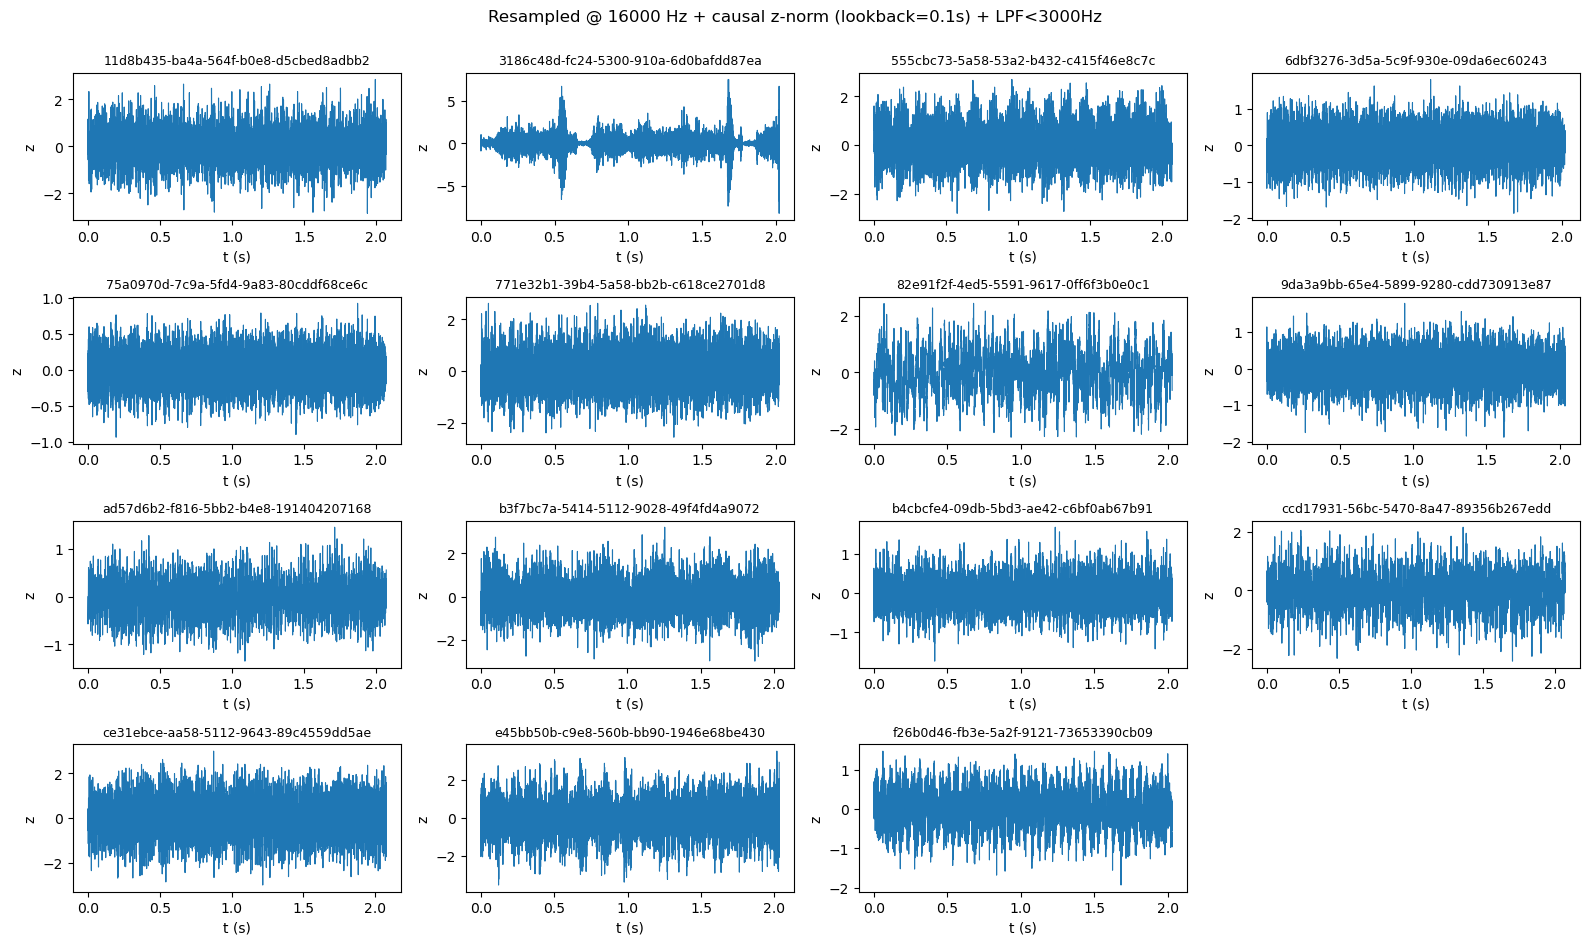

In [ ]:
# Resample + z-normalize using fixed stats from the first buffer (+ optional low-pass), then plot
fs_target = 16000.0          # Hz (change if you want a different uniform sampling rate)
buffer_seconds = 0.1         # seconds at the START used to compute mean/std for the whole signal
drop_first_buffer = False    # True if you want to hide the initial buffer region

# Optional smoothing near end of pipeline (applied after z-norm, before FFT)
lowpass_cutoff_hz = 3000.0   # set to None to disable
lowpass_order = 4
lowpass_zero_phase = False   # False=causal (no future), True=uses future samples (cleaner phase)

loader = Part2WaveDataLoader()
raw_series = waves_from_loader(loader)
proc_series = [
    preprocess_resample_and_znorm(
        s,
        fs=fs_target,
        buffer_seconds=buffer_seconds,
        drop_first_buffer=drop_first_buffer,
        lowpass_cutoff_hz=lowpass_cutoff_hz,
        lowpass_order=lowpass_order,
        lowpass_zero_phase=lowpass_zero_phase,
    )
    for s in raw_series
 ]

plot_series_grid(
    proc_series,
    max_points=5000,
    x_label="t (s)",
    y_label="z",
    title=(
        f"Resampled @ {fs_target:g} Hz + z-norm (fixed stats from first {buffer_seconds}s)"
        + (f" + LPF<{lowpass_cutoff_hz:g}Hz" if lowpass_cutoff_hz is not None else "")
    ),
)

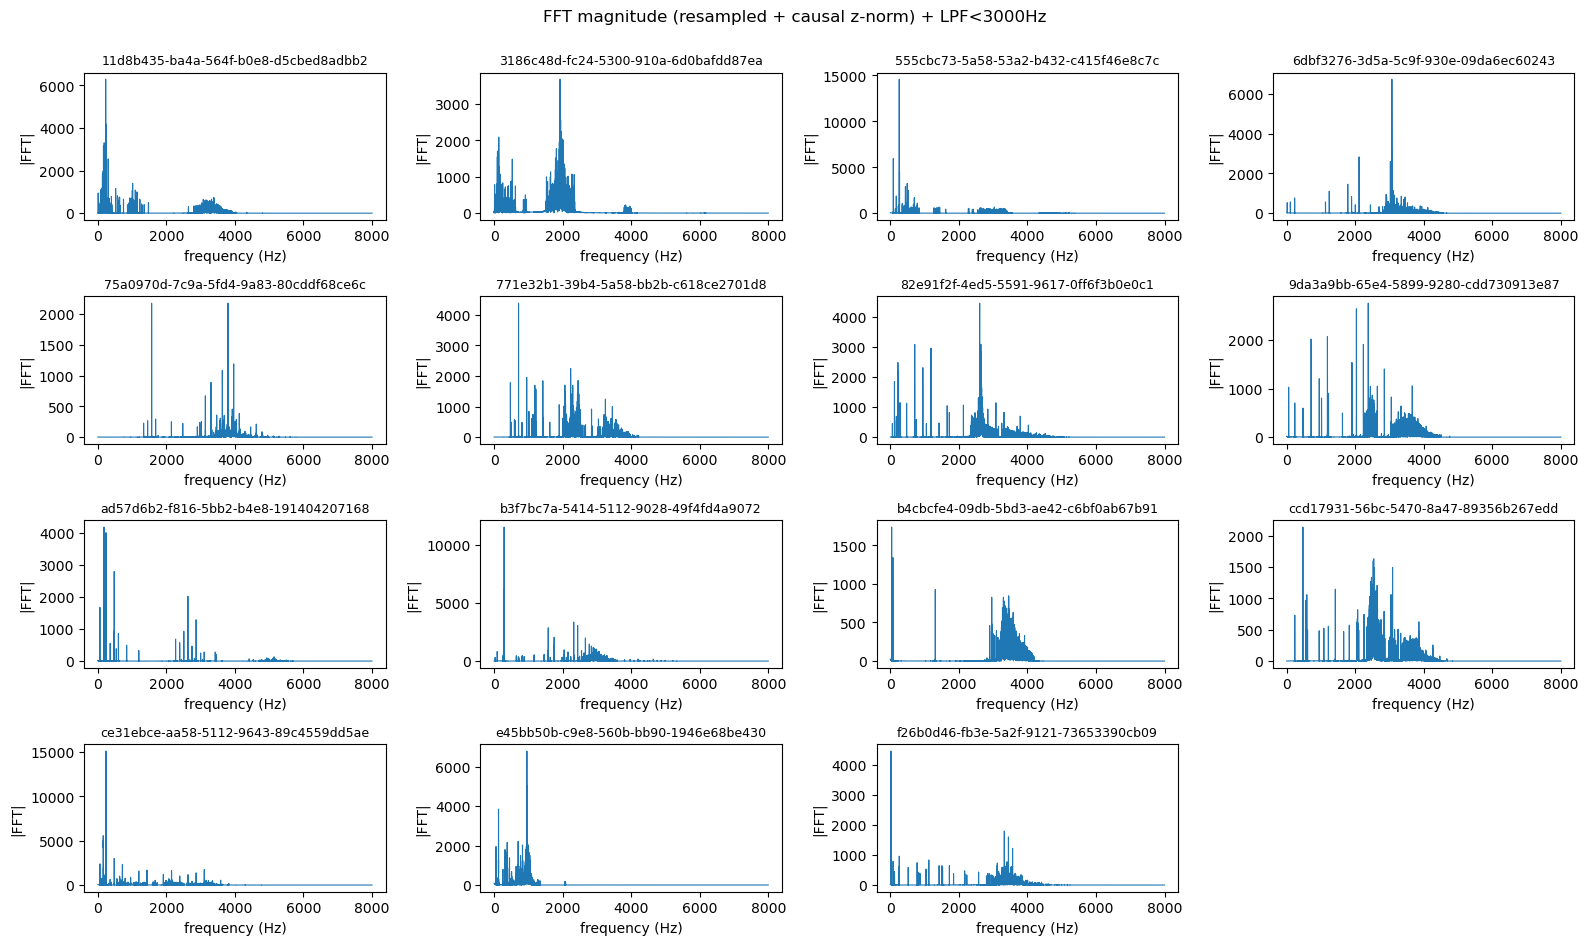

In [7]:
# FFT all resampled + z-normalized signals, then plot spectra
spectra: list[Series] = []
for s in proc_series:
    freqs, mag = fft_magnitude(s.x, fs=fs_target)
    spectra.append(Series(series_id=s.series_id, t=freqs, x=mag))

# Optionally zoom in on a frequency range (Hz)
freq_xlim = None  # e.g. (0, 2000)

fft_title = "FFT magnitude (resampled + causal z-norm)"
if lowpass_cutoff_hz is not None:
    fft_title += f" + LPF<{lowpass_cutoff_hz:g}Hz"

plot_series_grid(
    spectra,
    max_points=None,
    x_label="frequency (Hz)",
    y_label="|FFT|",
    title=fft_title,
    xlim=freq_xlim,
)

11d8b435-ba4a-564f-b0e8-d5cbed8adbb2 [(1000.24, 1099.83), (2628.96, 3960.36)]


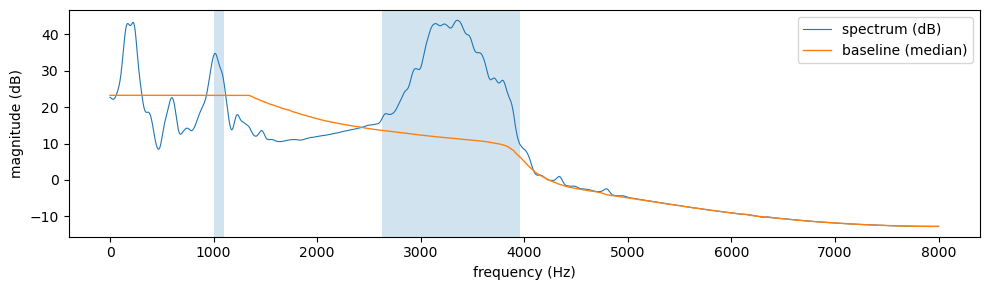

3186c48d-fc24-5300-910a-6d0bafdd87ea [(1173.8, 2439.99), (3747.68, 4000.62)]


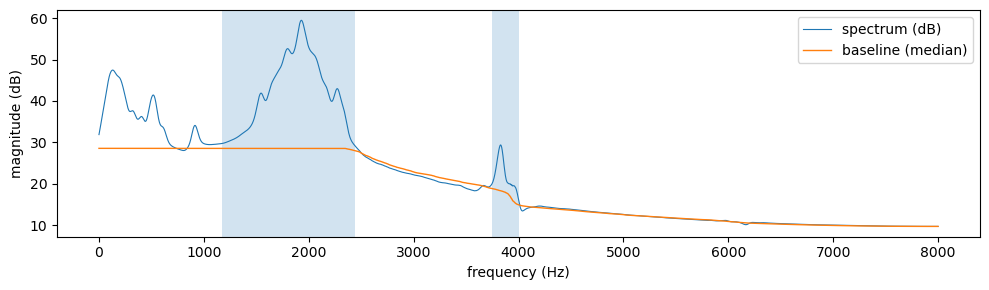

555cbc73-5a58-53a2-b432-c415f46e8c7c [(2836.52, 2911.9), (3089.73, 3389.33)]


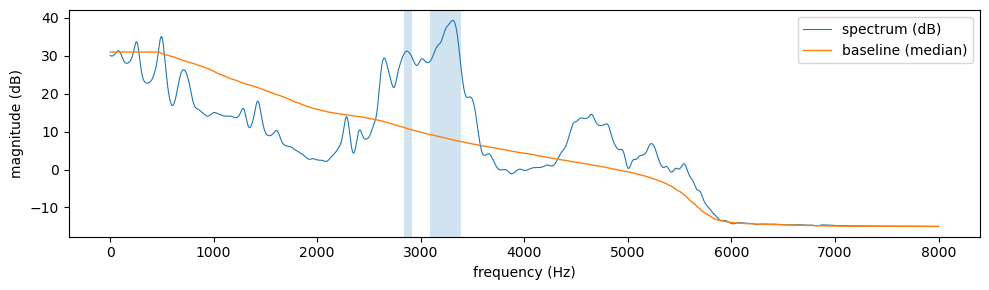

6dbf3276-3d5a-5c9f-930e-09da6ec60243 [(2971.56, 4266.4), (4370.15, 4435.85)]


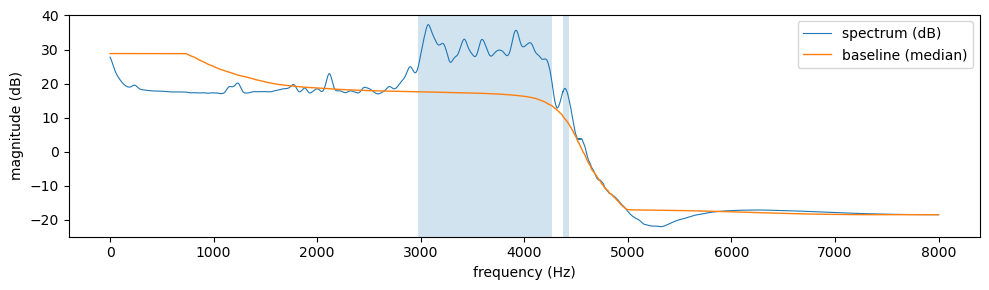

75a0970d-7c9a-5fd4-9a83-80cddf68ce6c [(2944.84, 3031.21), (3107.45, 4525.11), (4543.92, 4698.81), (4730.18, 4840.19)]


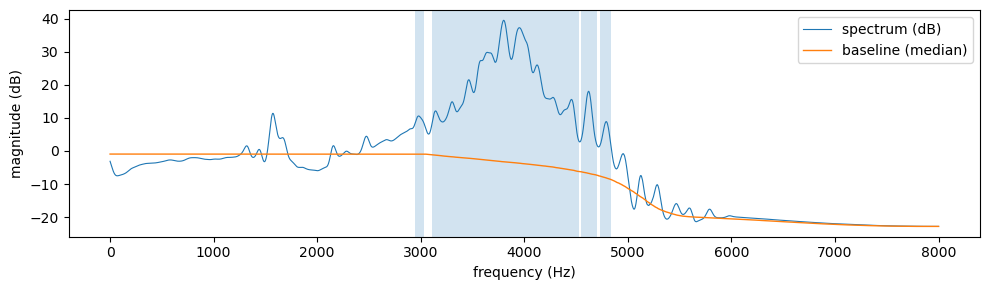

771e32b1-39b4-5a58-bb2b-c618ce2701d8 [(1000.28, 2705.3), (2788.32, 3956.63)]


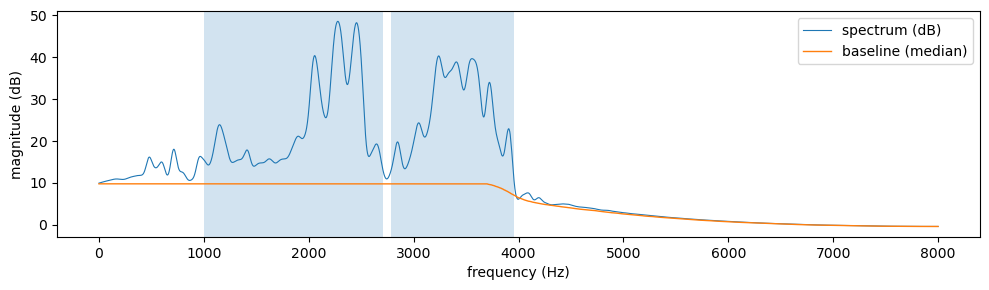

82e91f2f-4ed5-5591-9617-0ff6f3b0e0c1 [(2481.17, 2732.89)]


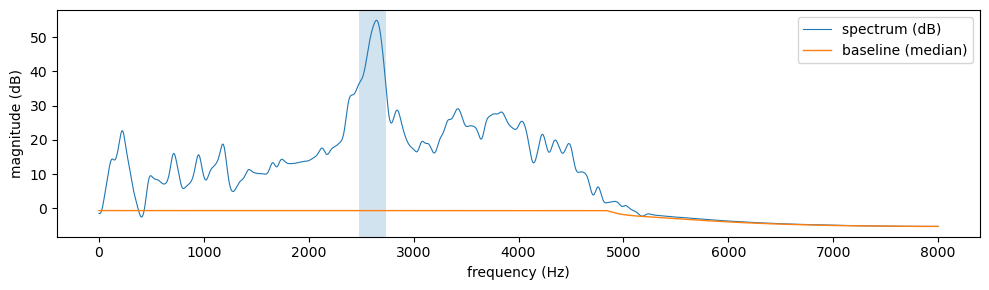

9da3a9bb-65e4-5899-9280-cdd730913e87 [(2415.51, 2573.57), (3206.28, 4252.79)]


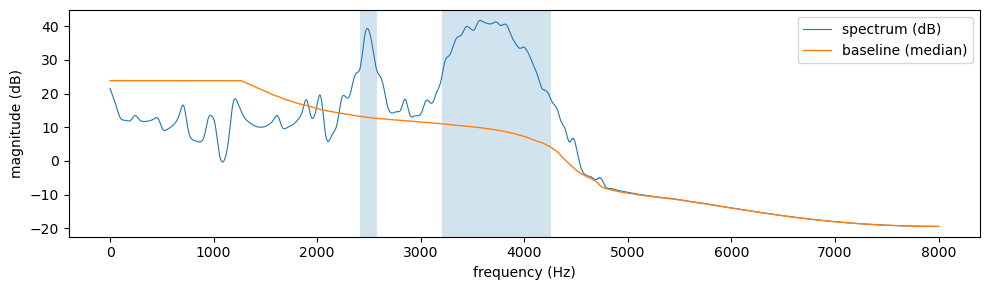

ad57d6b2-f816-5bb2-b4e8-191404207168 [(4751.41, 4804.0), (4854.67, 5419.71)]


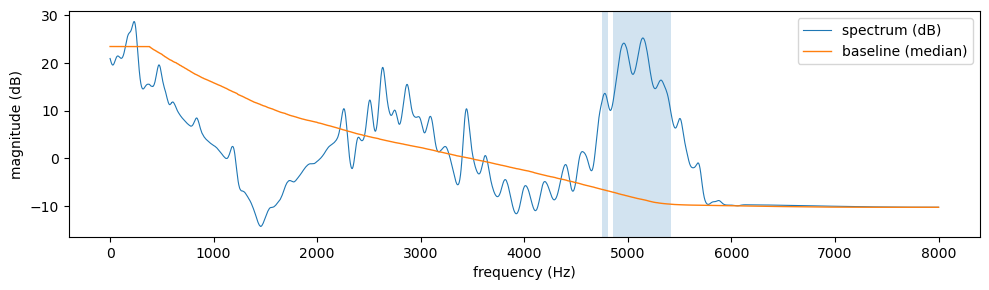

b3f7bc7a-5414-5112-9028-49f4fd4a9072 [(2403.14, 2494.04), (2518.61, 3502.27)]


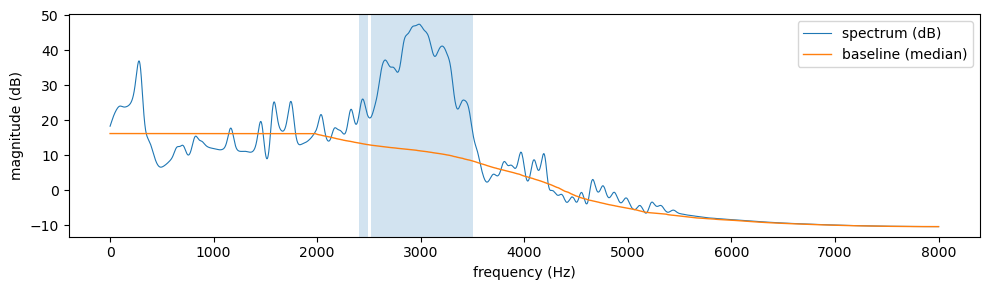

b4cbcfe4-09db-5bd3-ae42-c6bf0ab67b91 [(2925.84, 4189.76)]


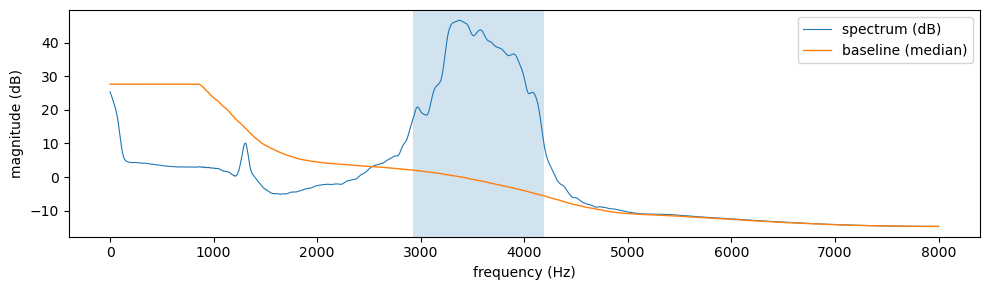

ccd17931-56bc-5470-8a47-89356b267edd [(2380.61, 2718.56), (3603.31, 3879.86)]


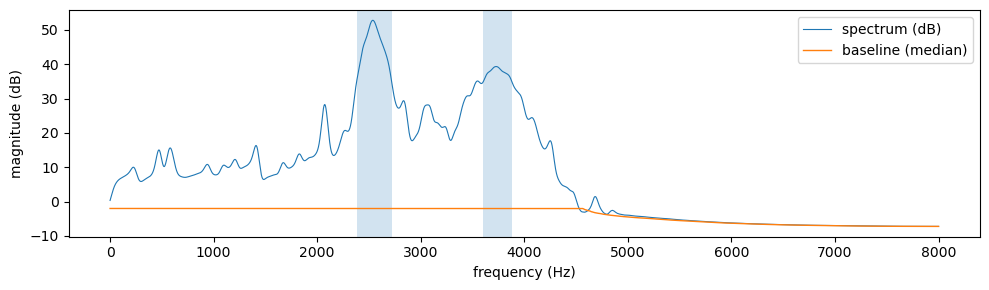

ce31ebce-aa58-5112-9643-89c4559dd5ae [(1882.21, 2469.65), (2590.99, 2661.77), (2813.93, 2908.3), (3037.83, 3652.71), (3749.5, 3849.65)]


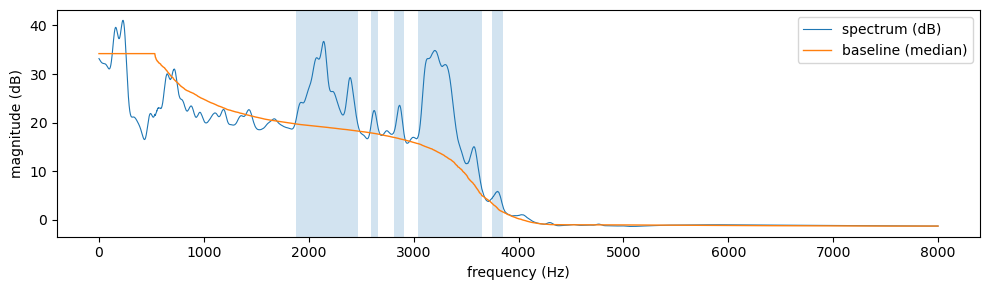

e45bb50b-c9e8-560b-bb90-1946e68be430 [(1000.18, 1141.87), (2903.14, 3288.36)]


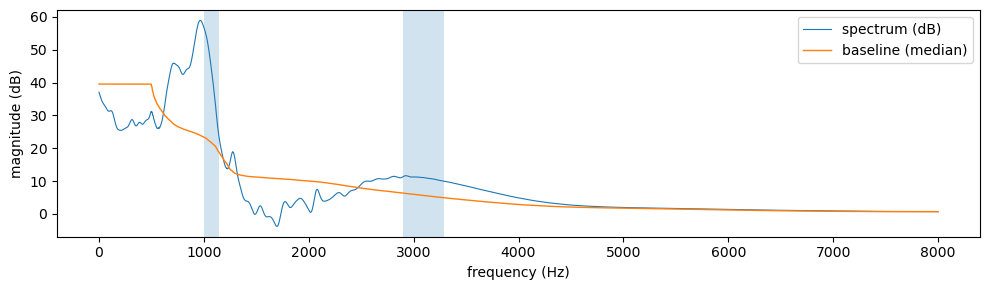

f26b0d46-fb3e-5a2f-9121-73653390cb09 [(3067.66, 4010.46), (4222.16, 4367.4)]


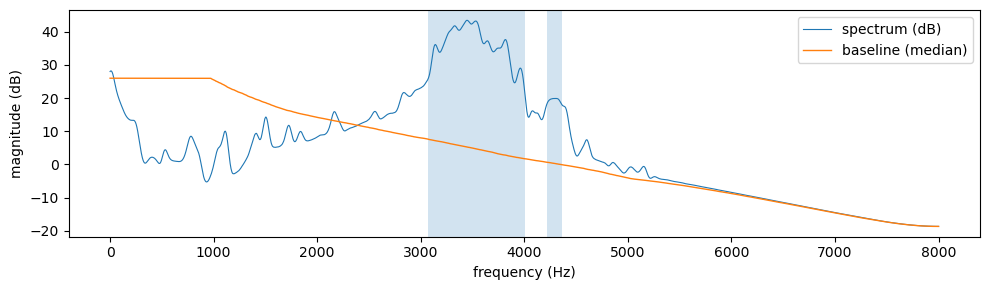

In [8]:
# Detect carpet regions from each FFT spectrum
baseline_kernel_hz = 16000.0     # median baseline window in Hz
smooth_sigma_hz = 25.0         # frequency-axis smoothing ("low-pass"), in Hz; set None to disable
z_thresh = 2.75                # higher => fewer regions
min_band_hz = 50.0            # reject narrow bands (not "carpet")
bridge_gap_hz = 10.0           # debouncer: bridge OFF-gaps up to this size (Hz)

# Hard rule: anything below 1000 Hz is NOT carpet
fmin_hz = 1000.0
fmax_hz = None  # e.g. 2000.0

carpet_regions_by_sample: dict[str, list[CarpetRegion]] = {}
for spec in spectra:
    regions, _ = detect_carpet_regions_fft(
        spec.t,
        spec.x,
        baseline_kernel_hz=baseline_kernel_hz,
        smooth_sigma_hz=smooth_sigma_hz,
        bridge_gap_hz=bridge_gap_hz,
        z_thresh=z_thresh,
        min_band_hz=min_band_hz,
        fmin_hz=fmin_hz,
        fmax_hz=fmax_hz,
    )
    carpet_regions_by_sample[spec.series_id] = regions

# Print results
for sample_id in sorted(carpet_regions_by_sample.keys()):
    regs = carpet_regions_by_sample[sample_id]
    pretty = [(round(r.start_hz, 2), round(r.end_hz, 2)) for r in regs]
    print(sample_id, pretty)

    spec0 = next(s for s in spectra if s.series_id == sample_id)
    regs0 = carpet_regions_by_sample[sample_id]
    plot_spectrum_with_regions(
        spec0.t,
        spec0.x,
        regs0,
        baseline_kernel_hz=baseline_kernel_hz,
        smooth_sigma_hz=smooth_sigma_hz,
        xlim=freq_xlim,
    )

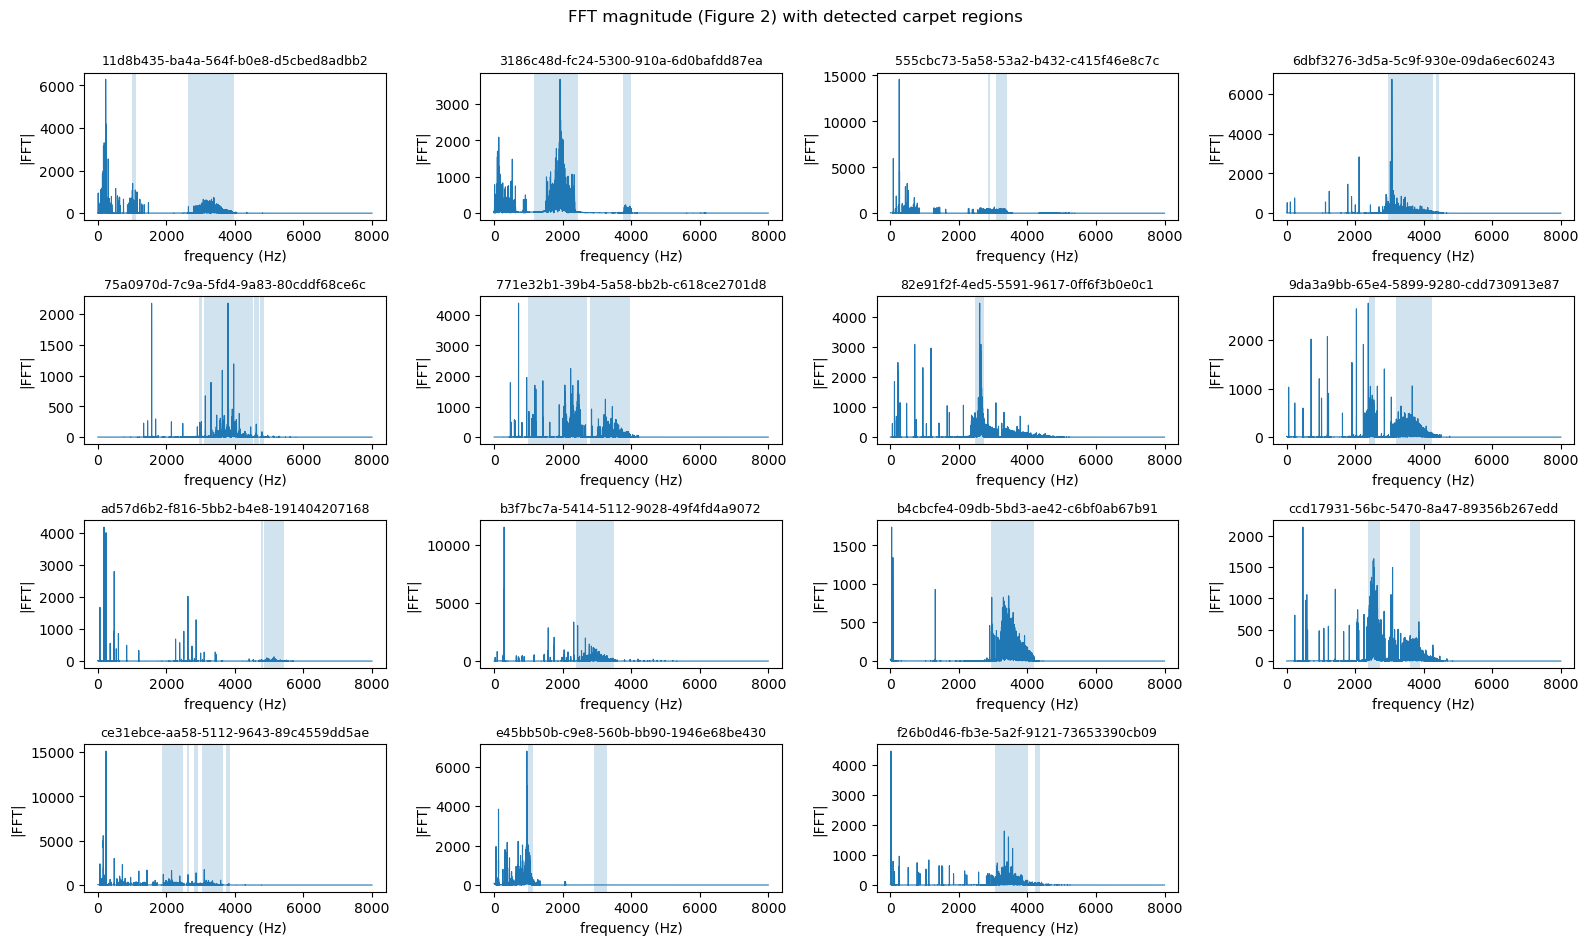

In [9]:
# Figure 2 overlay: FFT magnitude with detected carpet regions shaded
import math
import matplotlib.pyplot as plt
import numpy as np


def plot_fft_grid_with_regions(
    spectra: list[Series],
    regions_by_sample: dict[str, list[CarpetRegion]],
    *,
    ncols: int = 4,
    max_points: int | None = None,
    xlim: tuple[float, float] | None = None,
    title: str | None = None,
    y_label: str = "|FFT|",
 ) -> None:
    n = len(spectra)
    nrows = max(1, math.ceil(n / ncols))
    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(4.0 * ncols, 2.4 * nrows),
        sharex=False,
        sharey=False,
    )
    axes = axes.flatten() if hasattr(axes, "flatten") else [axes]
    for ax_i, ax in enumerate(axes):
        if ax_i >= n:
            ax.axis("off")
            continue
        s = spectra[ax_i]
        freqs = np.asarray(s.t, dtype=float)
        mag = np.asarray(s.x, dtype=float)
        if max_points is not None and freqs.size > max_points:
            step = max(1, int(freqs.size // max_points))
            freqs = freqs[::step]
            mag = mag[::step]
        ax.plot(freqs, mag, linewidth=0.8)
        for r in regions_by_sample.get(s.series_id, []):
            ax.axvspan(r.start_hz, r.end_hz, alpha=0.2)
        ax.set_title(s.series_id, fontsize=9)
        ax.set_xlabel("frequency (Hz)")
        ax.set_ylabel(y_label)
        if xlim is not None:
            ax.set_xlim(*xlim)
    if title:
        fig.suptitle(title)
        fig.tight_layout(rect=(0, 0, 1, 0.98))
    else:
        fig.tight_layout()
    plt.show()


plot_fft_grid_with_regions(
    spectra,
    carpet_regions_by_sample,
    ncols=4,
    max_points=None,
    xlim=freq_xlim,
    title="FFT magnitude (Figure 2) with detected carpet regions",
 )